In [ ]:
#importing all the libraries to be used 
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
# importing the dataset and checking first 5 rows of the dataset for analysis purpose
df = pd.read_csv("data/USA_Housing.csv")

df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [ ]:
#doing basic exploartion of dataset to understand for feature extraction and cleaning 
print("Shape:", df.shape)

df.info()

df.describe()

df.isnull().sum()

Shape: (5000, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

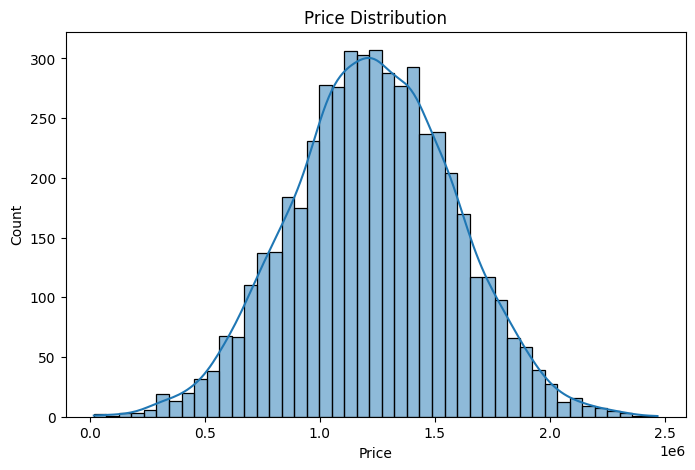

In [ ]:
# pre analysis of the target variable for understanding the distribution and pre extraction visualization
plt.figure(figsize=(8,5))

sns.histplot(df["Price"], kde=True)

plt.title("Price Distribution")

plt.show()

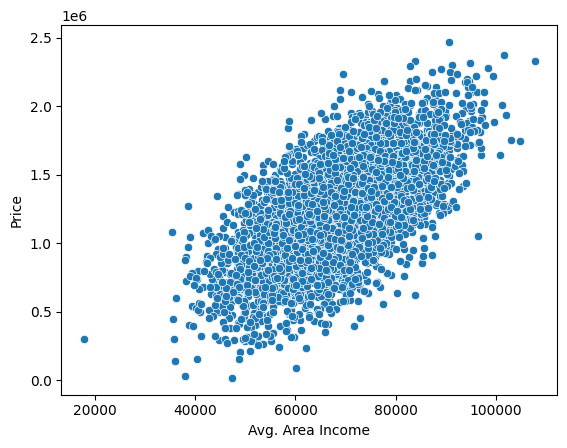

In [ ]:
# more visualization 
sns.scatterplot(
    x="Avg. Area Income",
    y="Price",
    data=df
)

plt.show()

In [6]:
X = df.drop(
    ["Price", "Address"],
    axis=1
)

y = df["Price"]

In [ ]:
# test train split for model training and evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# invoking the model and training phase of the model
model = LinearRegression()

model.fit(
    X_train,
    y_train
)

LinearRegression()

In [ ]:
# making predictions on the test set for evaluation of the model
predictions = model.predict(X_test)

predictions[:10]

array([1308587.92699759, 1237037.22949434, 1243429.34030681,
       1228900.2136037 , 1063320.9071083 , 1544058.05034861,
       1094774.70493019,  833284.72339225,  788412.85578719,
       1469714.86615709])

In [10]:
print(
    "MAE:",
    mean_absolute_error(
        y_test,
        predictions
    )
)

print(
    "MSE:",
    mean_squared_error(
        y_test,
        predictions
    )
)

print(
    "R2 Score:",
    r2_score(
        y_test,
        predictions
    )
)

MAE: 80879.09723489822
MSE: 10089009300.894522
R2 Score: 0.9179971706834288


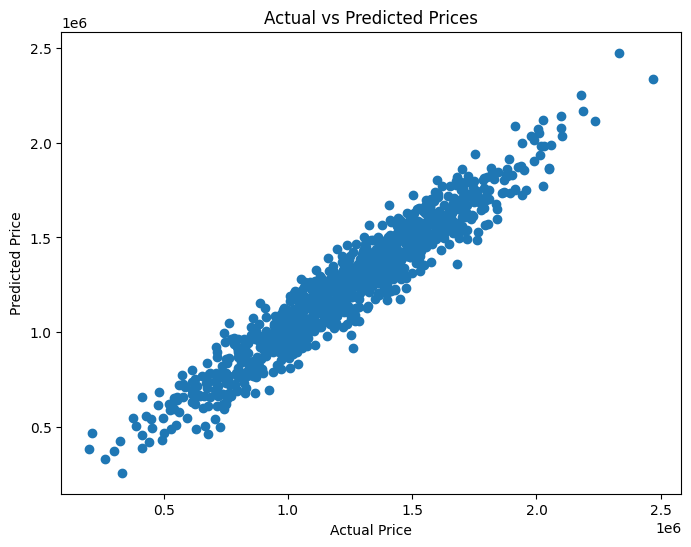

In [ ]:
# final visualization of the actual vs predicted values for final evaluation of the model performance
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    predictions
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title(
    "Actual vs Predicted Prices"
)

plt.show()